### GOAL 
Notebook aims to disentangle HGSOC RNA data into 2+ data spaces (Cell Cycle Signal Space, Inteferon Signal Space, Cell Dissociation Signal Space, Cell Type Signal Space)

In [1]:
import sys
import os

# Get the directory containing the notebook
NOTEBOOK_DIR = os.getcwd()

# Compute project root (go up one level)
PROJECT_ROOT = os.path.abspath(os.path.join(NOTEBOOK_DIR, '..'))

# Add project root to path
if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

In [2]:
import scanpy as sc
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt

In [3]:
from src.data.umi_data import UMIVaeDataset
from src.celluntangler import utils
from src.celluntangler.models import Trainer
from src.celluntangler.models.nb_vae import NBVAE
from src.visualization.helpers import split_embeddings
from src.visualization.visualization_functions import visualize_poincare_from_lorentz, visualize_embedding

In [4]:
from src.paths.paths import FALLOPIAN_EPITHELIAL_PATH 

In [5]:
adata = sc.read_h5ad("../../../data/HGSOC/MALIGNANT_NONMALIGNANT_EPITHELIAL/epithelial_subset.h5ad")

In [6]:
adata.obs.columns.tolist()

['percent.mt',
 'percent.rb',
 'doublet',
 'sample',
 'batch',
 'patient_id',
 'S.Score',
 'G2M.Score',
 'Phase',
 'CC.Diff',
 'RNA_snn_res.0.3',
 'seurat_clusters',
 'nCount_RNA',
 'nFeature_RNA',
 'doublet_score',
 'cell_id',
 'cell_type_super',
 'RNA_snn_res.0.1',
 'RNA_snn_res.0.2',
 'cluster_label',
 'CD8.Cytotoxic.module',
 'CD8.Dysfunctional.module',
 'CD8.Naive.module',
 'CD8.Predysfunctional.module',
 'CIN.module',
 'CIN.responsive.Noncanonical.NFKB.targets.up.module',
 'CIN.responsive.Noncanonical.NFKB.targets.down.module',
 'Noncanonical.NFKB.regulators.up.module',
 'Noncanonical.NFKB.regulators.down.module',
 'Canonical.NFKB.regulators.module',
 'Interferon.regulators.module',
 'EMT.module',
 'Inflammation.module',
 'Motility.and.migration.module',
 'ISG.module',
 'SASP.module',
 'Myofibroblast.module',
 'Fibroblast.module',
 'Mesenchymal.stem.cell.module',
 'Pericytes.module',
 'Smooth.muscle.cell.module',
 'ER.stress.module',
 'IFNg.signaling.module',
 'Androgen.pathway',

Text(0.5, 1.0, 'S Score Distribution')

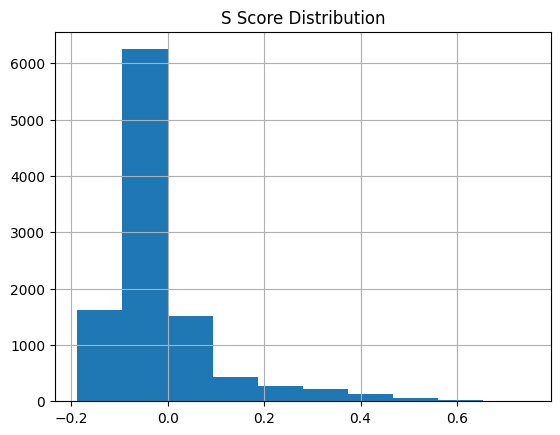

In [7]:
ax = adata.obs["S.Score"].hist()
ax.set_title("S Score Distribution")

### Pre-processing

In [7]:
adata.var["gene_symbols"] = adata.var["feature_name"]

In [8]:
cell_cycle_genes_path = "../../../genes/celluntangler_human_cell_cycle_genes.tsv"
interferon_genes_path = "../../../genes/HGSOC/llm_11_2025/human_interferon_genes.tsv" 
dissociation_genes_path = "../../../genes/HGSOC/llm_11_2025/human_cell_dissociation_genes.tsv" 

cell_cycle_genes = pd.read_csv(cell_cycle_genes_path, header = None, sep="\t")
interferon_genes = pd.read_csv(interferon_genes_path, header = None, sep="\t")
dissociation_genes = pd.read_csv(dissociation_genes_path, header = None, sep = "\t")

In [9]:
## Brief Analysis of Number of Relevant Genes Found 

In [10]:
cell_cycle_genes_set = set(cell_cycle_genes.iloc[:,0])
interferon_genes_set = set(interferon_genes.iloc[:,0]) 
dissociation_genes_set = set(dissociation_genes.iloc[:,0])

In [11]:
gene_sets = { "cell cycle genes": cell_cycle_genes_set, 
              "interferon genes": interferon_genes_set,
              "dissociation_genes": dissociation_genes_set }
for name0, genes0 in gene_sets.items():  
    for name1, genes1 in gene_sets.items() : 
        if (name0 != name1): 
            print(f"Intersection between: {name0}, {name1}") 
            print(genes0.intersection(genes1))

Intersection between: cell cycle genes, interferon genes
set()
Intersection between: cell cycle genes, dissociation_genes
set()
Intersection between: interferon genes, cell cycle genes
set()
Intersection between: interferon genes, dissociation_genes
set()
Intersection between: dissociation_genes, cell cycle genes
set()
Intersection between: dissociation_genes, interferon genes
set()


In [12]:
contained_genes_cc = adata.var["gene_symbols"].isin(cell_cycle_genes[0])
print(f"Number of cell cycle genes present in adata: {np.sum(contained_genes_cc)}")

contained_genes_interferon = adata.var["gene_symbols"].isin(interferon_genes[0])
print(f"Number of interferon genes present in adata: {np.sum(contained_genes_interferon)}")

contained_genes_dissociation = adata.var["gene_symbols"].isin(dissociation_genes[0])
print(f"Number of cell dissociation genes present in adata: {np.sum(contained_genes_dissociation)}")

Number of cell cycle genes present in adata: 214
Number of interferon genes present in adata: 12
Number of cell dissociation genes present in adata: 17


In [13]:
# Order Genes in adata such that genes appear in following order: cell cycle genes, interferon genes, dissociation genes

cc_indices = np.where(contained_genes_cc)[0]
interferon_indices = np.where(contained_genes_interferon)[0]
dissociation_indices = np.where(contained_genes_dissociation)[0]

all_known_indices = np.hstack((cc_indices, interferon_indices, dissociation_indices))
remaining_indices = np.setdiff1d(np.arange(adata.shape[1]), all_known_indices)

rearranged_indices = np.hstack((cc_indices, interferon_indices, dissociation_indices, remaining_indices))
rearranged_indices = rearranged_indices.astype(int)

In [14]:
rearranged_indices

array([  146,   241,   501, ..., 31090, 31091, 31092], shape=(31093,))

In [15]:
print(cc_indices.shape, interferon_indices.shape, dissociation_indices.shape, remaining_indices.shape)

(214,) (12,) (17,) (30850,)


In [16]:
adata = adata[:, rearranged_indices] # .copy() is safer in AnnData
adata.uns["new_gene_ordering"] = rearranged_indices # NB: this takes a while to run!

/var/folders/2z/f9h5sjqj6m9dz0ljc7yy_plw0000gn/T/ipykernel_30296/1082852305.py:2: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns["new_gene_ordering"] = rearranged_indices # NB: this takes a while to run!


### Creating Training Dataset

In [17]:
if not "batch" in adata.obs.columns.tolist(): 
    adata.obs["batch"] = adata.obs.index.str.split("_").str[0]
    adata.obs["batch"] = adata.obs["batch"].astype("category")

In [18]:
adata.obs["batch"].unique()

['SPECTRUM-OV-083', 'SPECTRUM-OV-070', 'SPECTRUM-OV-026', 'SPECTRUM-OV-009', 'SPECTRUM-OV-045', ..., 'SPECTRUM-OV-054', 'SPECTRUM-OV-090', 'SPECTRUM-OV-025', 'SPECTRUM-OV-080', 'SPECTRUM-OV-002']
Length: 41
Categories (41, object): ['SPECTRUM-OV-002', 'SPECTRUM-OV-003', 'SPECTRUM-OV-007', 'SPECTRUM-OV-008', ..., 'SPECTRUM-OV-112', 'SPECTRUM-OV-115', 'SPECTRUM-OV-116', 'SPECTRUM-OV-118']

In [19]:
batch = adata.obs.batch.cat.codes.values 
batch = batch[:,None]
batch = batch.astype(np.int64) 

In [20]:
np.unique(batch)

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34, 35, 36, 37, 38, 39, 40])

In [21]:
batch_counts = np.bincount(batch[:,0])
batch_counts = batch_counts[1:]

In [22]:
# Creating Training Dataset
x = adata.X.todense().astype(np.double)

# (ADDED) Normalize data so it is non-negative (maybe this is an implicit requirement for CellUntangler?)
min_val = x.min()
max_val = x.max()

# min-max scaling to [0,1]
x = (x - min_val) / (max_val - min_val)

In [40]:
# y holds the batch vector for the dataset
y = batch # TODO - figure out if batch effects are present in this dataset
in_dim = x.shape[1]
print(f"in_dim = {in_dim}")
batch_size = config.batch_size
dataset = UMIVaeDataset(batch_size=batch_size, in_dim=in_dim)
print(f"dataset.in_dim = {dataset.in_dim}")
# Create the dataset loaders
train_loader = dataset.create_loaders(x, y, seed=config.seed)

in_dim = 31093
dataset.in_dim = 31093
Dataset seed: 68715


In [41]:
# Creating (Disjoint) Masks
mask_cyc = np.zeros(adata.n_vars)
mask_cyc[adata.var["gene_symbols"].isin(cell_cycle_genes[0])] = 1
mask_interferon = np.zeros(adata.n_vars)
mask_interferon[adata.var["gene_symbols"].isin(interferon_genes[0])] = 1
mask_dissociation = np.zeros(adata.n_vars) 
mask_dissociation[adata.var["gene_symbols"].isin(dissociation_genes[0])] = 1

mask_all = np.ones(adata.n_vars)
mask_all[adata.var["gene_symbols"].isin(cell_cycle_genes[0])] = 0 
mask_all[adata.var["gene_symbols"].isin(interferon_genes[0])] = 0 
mask_all[adata.var["gene_symbols"].isin(dissociation_genes[0])] = 0 

mask = torch.tensor([mask_cyc, mask_interferon, mask_dissociation, mask_all])

### Configure Save Paths

In [43]:
epoch_embeddings_save_path = FALLOPIAN_EPITHELIAL_PATH
visualize_information={}
# The epochs to save the intermediate embeddings for
visualize_information["epochs"]=[i for i in range(0, 500, 50)] 
visualize_information["x"]=x
visualize_information["y"]=y
visualize_information["embeddings_save_path"]=epoch_embeddings_save_path
visualize_information["model_name"]=config.model_name
visualize_information["device"]=config.device

In [44]:
# TODO - add functionality for plotting a log-likelihood plot every 50 epochs or so

### Model Configuration

In [45]:
from src.celluntangler.models.get_config import get_config
config = get_config()
config.model_name = "e2, e10"
config.seed = 68715
config.init = "custom"
config.max_epochs = 100 # TODO - change to 500 once verified working 
config.epochs = 100 
# One entryb in n_batch for each "factor of batch effects"
config.n_batch = [ len(np.unique(batch)) ]

In [46]:
if config.seed:  
    torch.manual_seed(config.seed)
    np.random.seed(config.seed) 
    np.random.default_rng(config.seed)

model_name = "r2, e10, e10, e10" # TODO: choice of latent space geometry and number of dimensions could be improved
components = utils.parse_components(model_name, config.fixed_curvature) 

### Model Creation

In [47]:
use_gpu = False
if use_gpu:
  print("Using GPU")
  config.device = torch.device("mps")
else:
  print("Using CPU")
  config.device = torch.device("cpu")

Using CPU


In [48]:
torch.set_default_dtype(torch.float64)

In [49]:
component_subspaces = {0 :[0], 1: [0,1], 2:[0,1,2], 3: [0,1,2,3]}
component_no_grads = {1: [0], 2: [0,1], 3: [0,1,2]}

In [50]:
model = NBVAE(h_dim=config.h_dim,
              components=components,
              mask=mask,
              dataset=dataset,
              config=config,
              component_subspaces=component_subspaces,
              component_no_grads=component_no_grads).to(config.device)

Linear(in_features=32, out_features=2, bias=True)
initializing Xavier uniform weights in Linear
Linear(in_features=32, out_features=2, bias=True)
initializing Xavier uniform weights in Linear
RotatedHyperbolicComponent(R^3)


In [51]:
component_no_grads

{1: [0], 2: [0, 1], 3: [0, 1, 2]}

In [52]:
component_subspaces

{0: [0], 1: [0, 1], 2: [0, 1, 2], 3: [0, 1, 2, 3]}

### Analysis

In [54]:
gene_expression_matrix_path = epoch_embeddings_save_path

In [56]:
embeddings = np.loadtxt(os.path.join(epoch_embeddings_save_path, f'{model_name}_all_encode_v63_z_params.txt'))
component_embeddings = split_embeddings(model_name, embeddings)
for c in component_embeddings:
    adata.obsm[c] = component_embeddings[c]

r2 3
e10 10
e10 10
e10 10


#### Visualization of Component 1 (R2)

##### Visualization fo Cell Cycle Signals

/Users/jeromecho/Library/CloudStorage/OneDrive-Personal/Thesis/code/CellUntangler/src/visualization/visualization_functions.py:179: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='upper right', bbox_to_anchor=bbox_to_anchor)


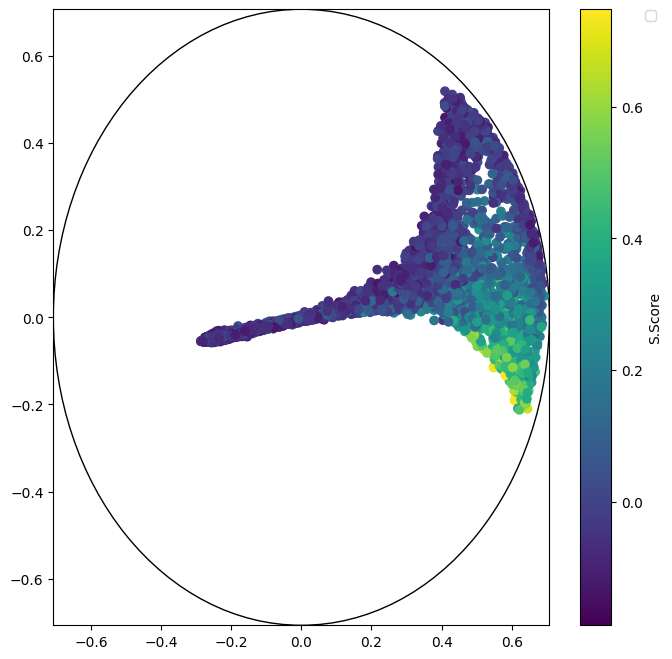

In [57]:
embeddings_key = "component1_r2"
desired_obs = 'S.Score'
desired_obs_all = adata.obs[desired_obs]
legend_coordinates = (1.23,1.01)
fig = visualize_poincare_from_lorentz(adata.obsm[embeddings_key],
                       desired_obs_all,
                       curvature=-2,
                      embedding_type='continuous',
                       cmap=plt.cm.viridis,
                       cat_colors=None,
                      grid_lines=True,
                      c_bar_label="S.Score",
                      bbox_to_anchor=legend_coordinates)

Index(['G1', 'G2M', 'S'], dtype='object')


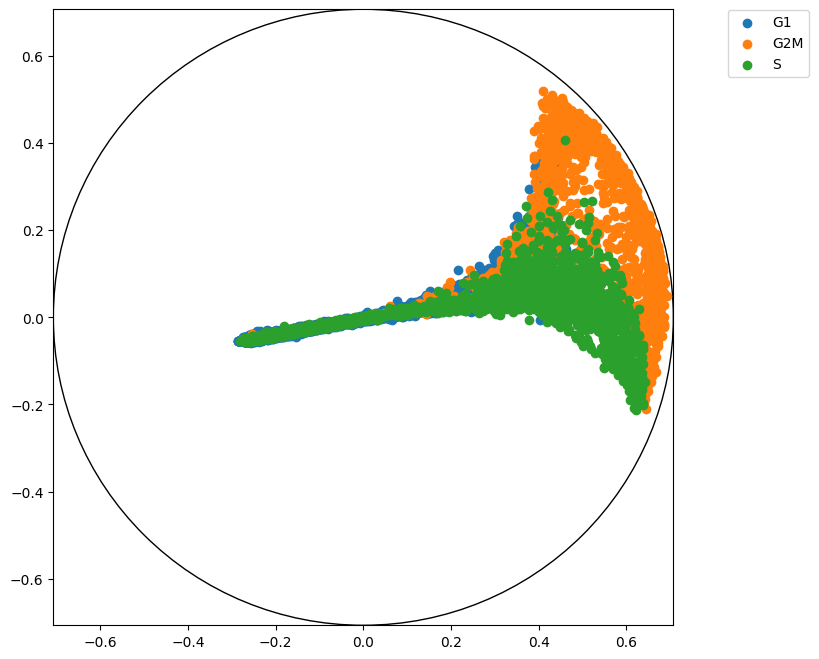

In [71]:
embeddings_key = "component1_r2"
desired_obs = 'Phase'
desired_obs_all = adata.obs[desired_obs]
legend_coordinates = (1.23,1.01)
fig = visualize_poincare_from_lorentz(adata.obsm[embeddings_key],
                       desired_obs_all,
                       curvature=-2,
                      embedding_type='discrete',
                       cmap=plt.cm.viridis,
                       cat_colors=None,
                      grid_lines=True,
                      c_bar_label="Phase",
                      bbox_to_anchor=legend_coordinates)

In [73]:
adata.obsm[embeddings_key]

array([[ 0.9481343 ,  0.54542878, -0.31853747],
       [ 0.72780428,  0.08008249, -0.15259711],
       [ 0.85418858, -0.21721714, -0.42714736],
       ...,
       [ 3.80574553, -3.40690923, -1.54164475],
       [ 0.97652252, -0.55860972,  0.37623321],
       [ 1.35101539,  1.11012083, -0.30475292]], shape=(10505, 3))

#### Visualization of Component 2 (E10)

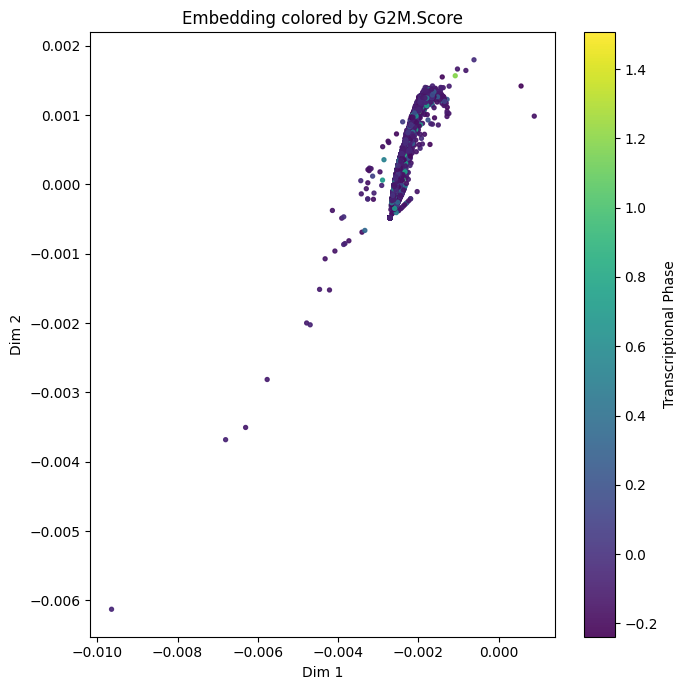

In [59]:
# For preliminary analysis - just measure enrichment in some marker gene of interferon response
embeddings_key = "component2_e10"
desired_obs = 'G2M.Score'

visualize_embedding(
    embedding=adata.obsm[embeddings_key],
    obs_values=adata.obs[desired_obs],
    cmap=plt.cm.viridis,
    c_bar_label="Transcriptional Phase",
    bbox_to_anchor=(1.23, 1.01)
)

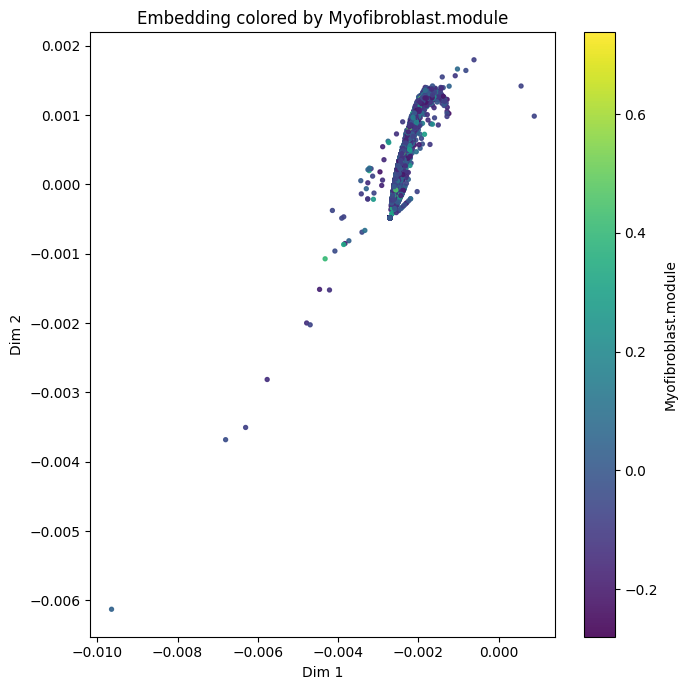

In [73]:
# For preliminary analysis - just measure enrichment in some marker gene of interferon response
embeddings_key = "component2_e10"
desired_obs = 'Myofibroblast.module'

visualize_embedding(
    embedding=adata.obsm[embeddings_key],
    obs_values=adata.obs[desired_obs],
    cmap=plt.cm.viridis,
    c_bar_label="Myofibroblast.module",
    bbox_to_anchor=(1.23, 1.01)
)

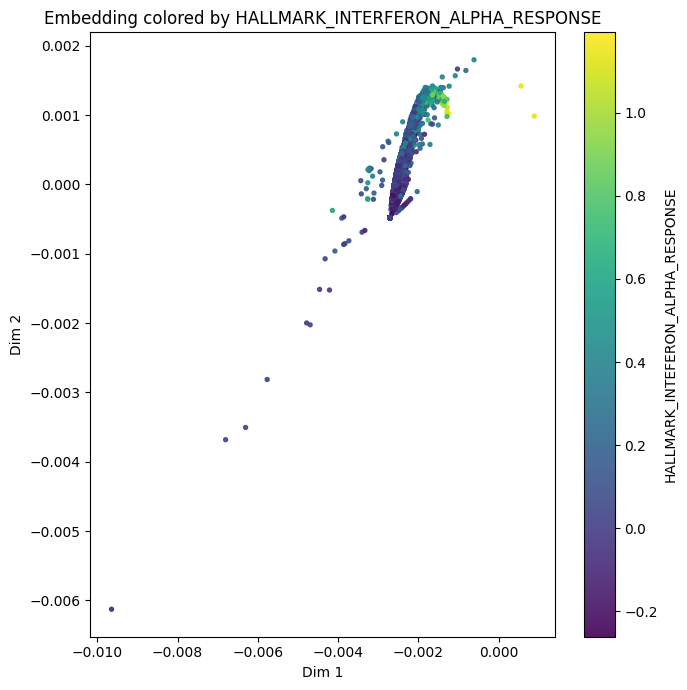

In [72]:
# For preliminary analysis - just measure enrichment in some marker gene of interferon response
embeddings_key = "component2_e10"
desired_obs = 'HALLMARK_INTERFERON_ALPHA_RESPONSE'

visualize_embedding(
    embedding=adata.obsm[embeddings_key],
    obs_values=adata.obs[desired_obs],
    cmap=plt.cm.viridis,
    c_bar_label="HALLMARK_INTEFERON_ALPHA_RESPONSE",
    bbox_to_anchor=(1.23, 1.01)
)

/var/folders/2z/f9h5sjqj6m9dz0ljc7yy_plw0000gn/T/ipykernel_55394/3699273278.py:22: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  is_categorical = pd.api.types.is_categorical_dtype(obs_values)


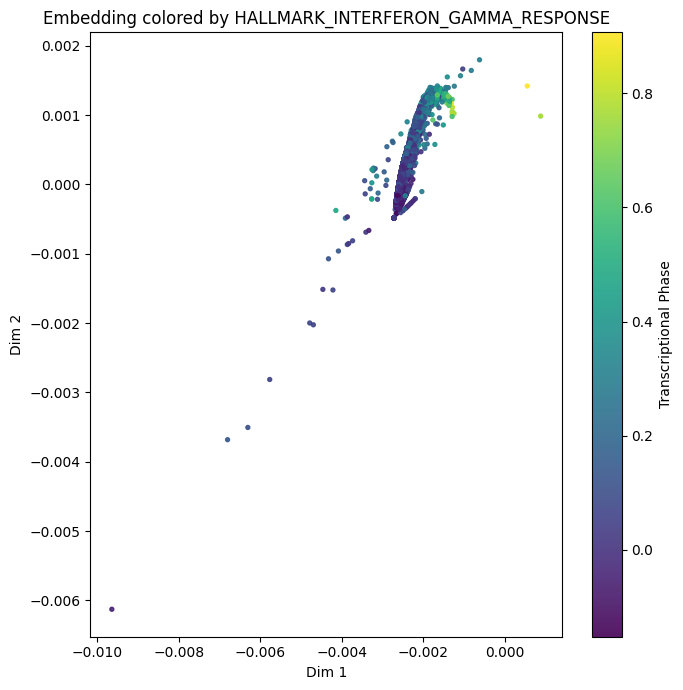

In [48]:
# For preliminary analysis - just measure enrichment in some marker gene of interferon response
embeddings_key = "component2_e10"
desired_obs = 'HALLMARK_INTERFERON_GAMMA_RESPONSE'

visualize_embedding(
    embedding=adata.obsm[embeddings_key],
    obs_values=adata.obs[desired_obs],
    cmap=plt.cm.viridis,
    c_bar_label="Transcriptional Phase",
    bbox_to_anchor=(1.23, 1.01)
)

#### Visualization of Component 3 (E10)

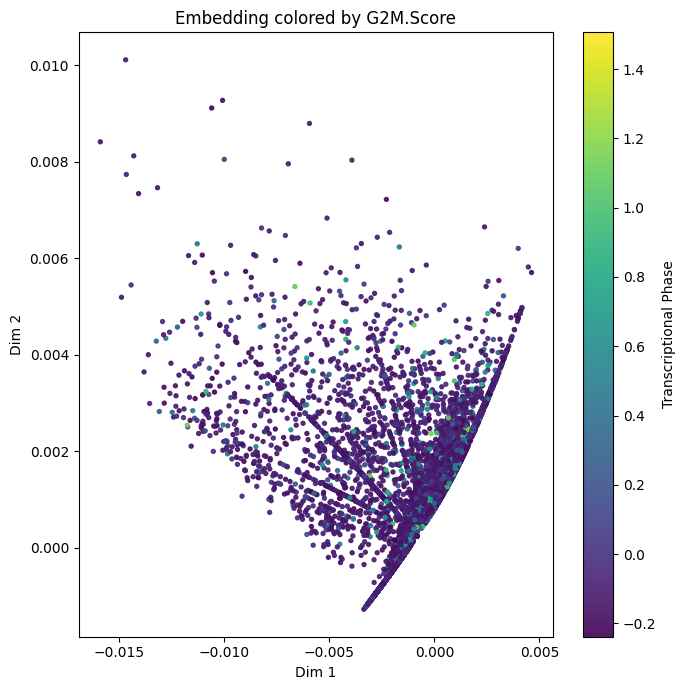

In [74]:
##### TODO - add custom UMAP code that doesn't hang! 
# For preliminary analysis - just measure enrichment in some marker gene of cell dissociation response
# For preliminary analysis - just measure enrichment in some marker gene of interferon response
embeddings_key = "component3_e10"
desired_obs = 'G2M.Score'

visualize_embedding(
    embedding=adata.obsm[embeddings_key],
    obs_values=adata.obs[desired_obs],
    cmap=plt.cm.viridis,
    c_bar_label="Transcriptional Phase",
    bbox_to_anchor=(1.23, 1.01)
)

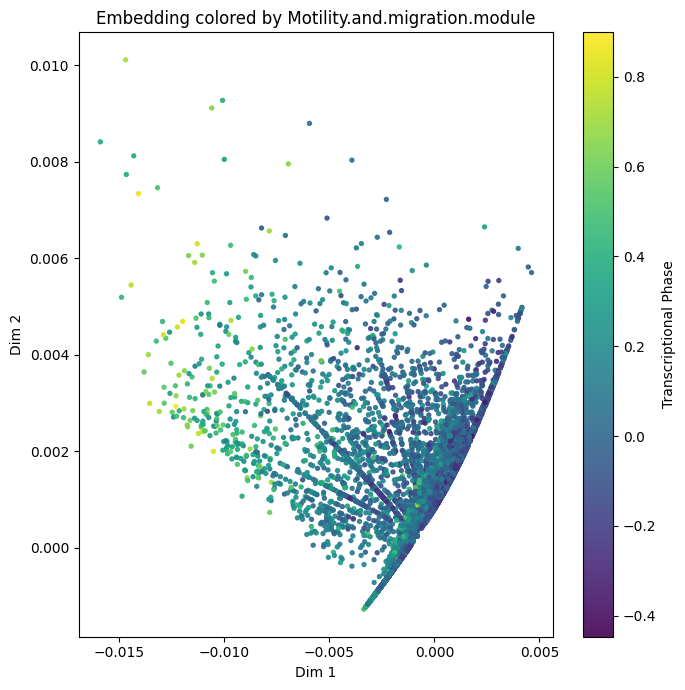

In [75]:
# TODO - add custom UMAP code that doesn't hang! 
# For preliminary analysis - just measure enrichment in some marker gene of cell dissociation response
# For preliminary analysis - just measure enrichment in some marker gene of interferon response
embeddings_key = "component3_e10"
desired_obs = 'Motility.and.migration.module'

visualize_embedding(
    embedding=adata.obsm[embeddings_key],
    obs_values=adata.obs[desired_obs],
    cmap=plt.cm.viridis,
    c_bar_label="Transcriptional Phase",
    bbox_to_anchor=(1.23, 1.01)
)

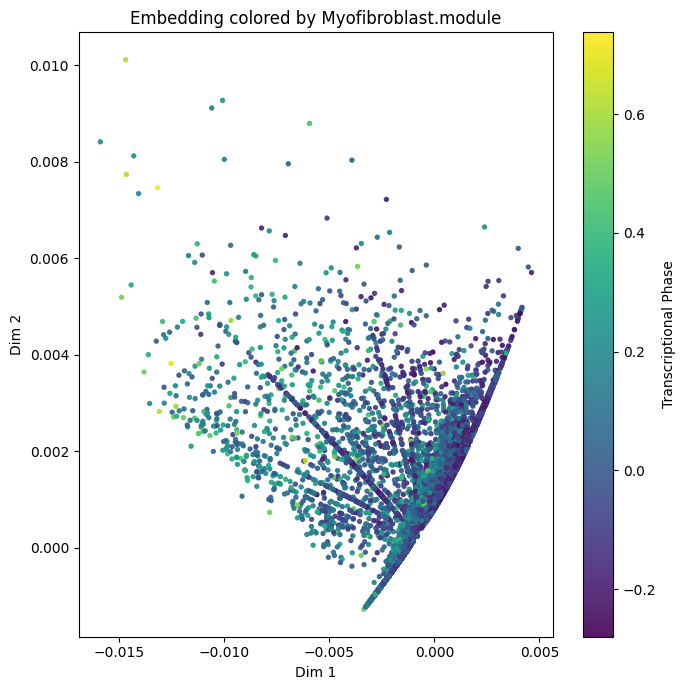

In [76]:
# TODO - add custom UMAP code that doesn't hang! 
# For preliminary analysis - just measure enrichment in some marker gene of cell dissociation response
# For preliminary analysis - just measure enrichment in some marker gene of interferon response
embeddings_key = "component3_e10"
desired_obs = 'Myofibroblast.module'

visualize_embedding(
    embedding=adata.obsm[embeddings_key],
    obs_values=adata.obs[desired_obs],
    cmap=plt.cm.viridis,
    c_bar_label="Transcriptional Phase",
    bbox_to_anchor=(1.23, 1.01)
)

#### Visualization of Component 4 (E10)

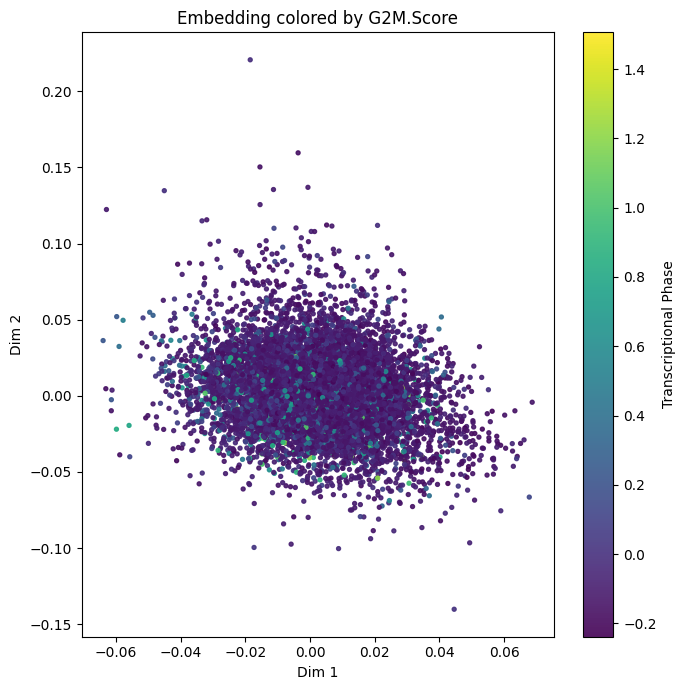

In [58]:
# TODO - add custom UMAP code that doesn't hang! 
# Visualize UMAP using cell cycle ground truth, cell type ground truth, other labels, .... 
# TODO - add custom UMAP code that doesn't hang! 
# For preliminary analysis - just measure enrichment in some marker gene of cell dissociation response
# For preliminary analysis - just measure enrichment in some marker gene of interferon response
embeddings_key = "component4_e10"
desired_obs = ''

visualize_embedding(
    embedding=adata.obsm[embeddings_key],
    obs_values=adata.obs[desired_obs],
    cmap=plt.cm.viridis,
    c_bar_label="Transcriptional Phase",
    bbox_to_anchor=(1.23, 1.01)
)

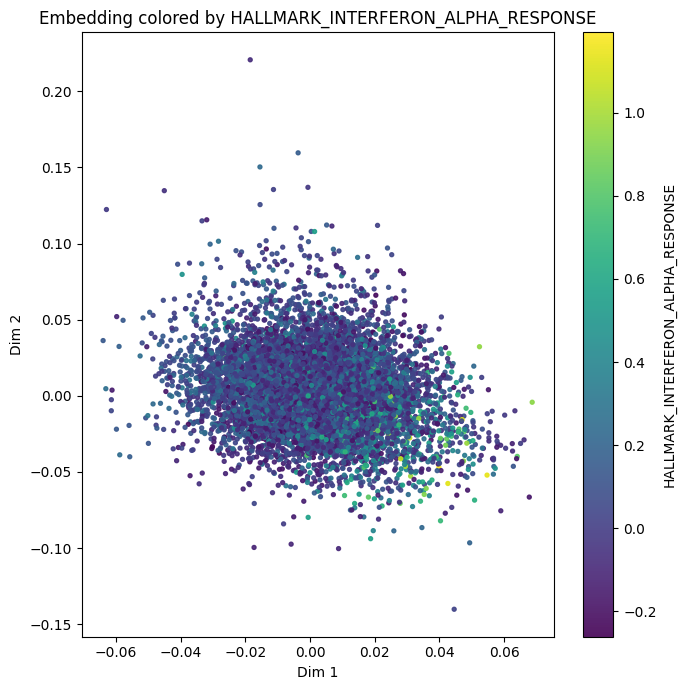

In [59]:
embeddings_key = "component4_e10"
desired_obs = 'HALLMARK_INTERFERON_ALPHA_RESPONSE'

visualize_embedding(
    embedding=adata.obsm[embeddings_key],
    obs_values=adata.obs[desired_obs],
    cmap=plt.cm.viridis,
    c_bar_label="HALLMARK_INTERFERON_ALPHA_RESPONSE",
    bbox_to_anchor=(1.23, 1.01)
)

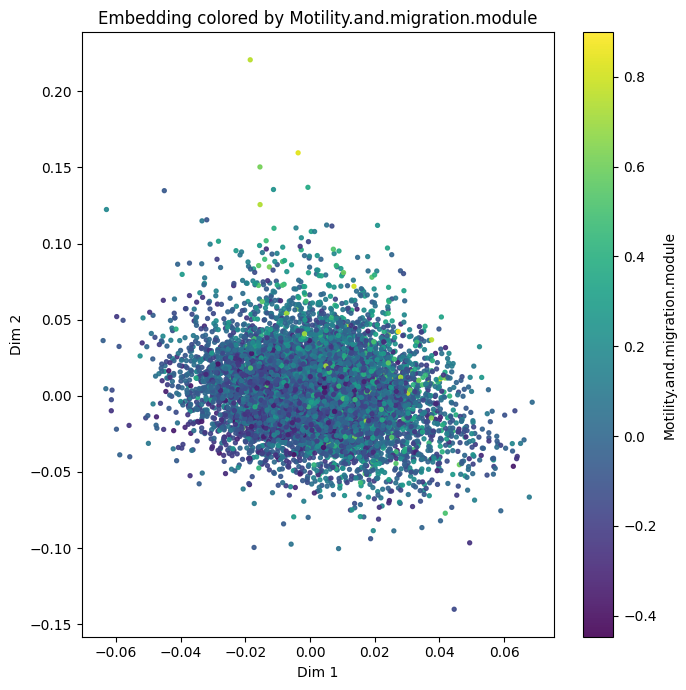

In [60]:
embeddings_key = "component4_e10"
desired_obs = 'Motility.and.migration.module'

visualize_embedding(
    embedding=adata.obsm[embeddings_key],
    obs_values=adata.obs[desired_obs],
    cmap=plt.cm.viridis,
    c_bar_label="Motility.and.migration.module",
    bbox_to_anchor=(1.23, 1.01)
)

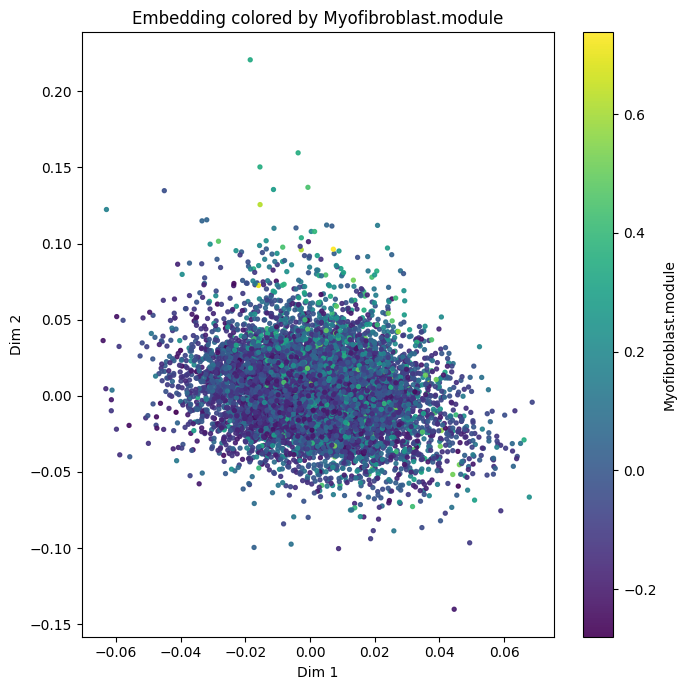

In [61]:
embeddings_key = "component4_e10"
desired_obs = 'Myofibroblast.module'

visualize_embedding(
    embedding=adata.obsm[embeddings_key],
    obs_values=adata.obs[desired_obs],
    cmap=plt.cm.viridis,
    c_bar_label="Myofibroblast.module",
    bbox_to_anchor=(1.23, 1.01)
)

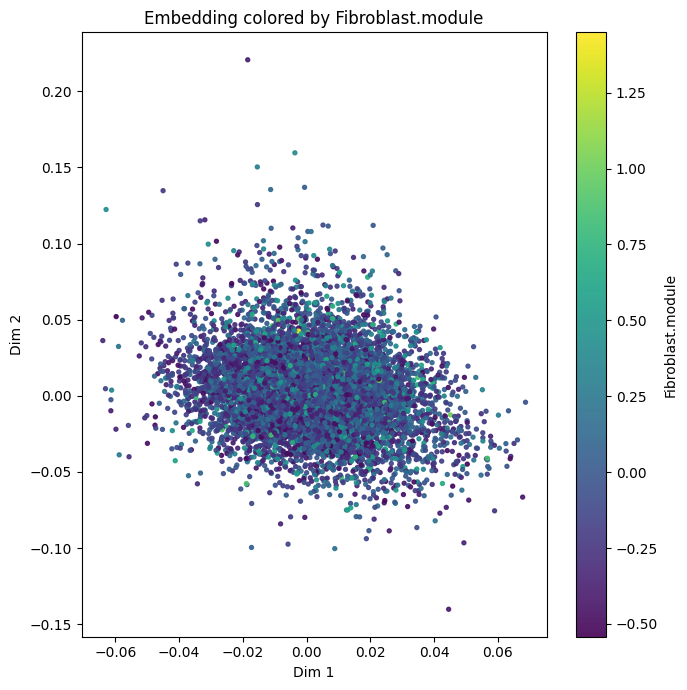

In [62]:
embeddings_key = "component4_e10"
desired_obs = 'Fibroblast.module'

visualize_embedding(
    embedding=adata.obsm[embeddings_key],
    obs_values=adata.obs[desired_obs],
    cmap=plt.cm.viridis,
    c_bar_label="Fibroblast.module",
    bbox_to_anchor=(1.23, 1.01)
)

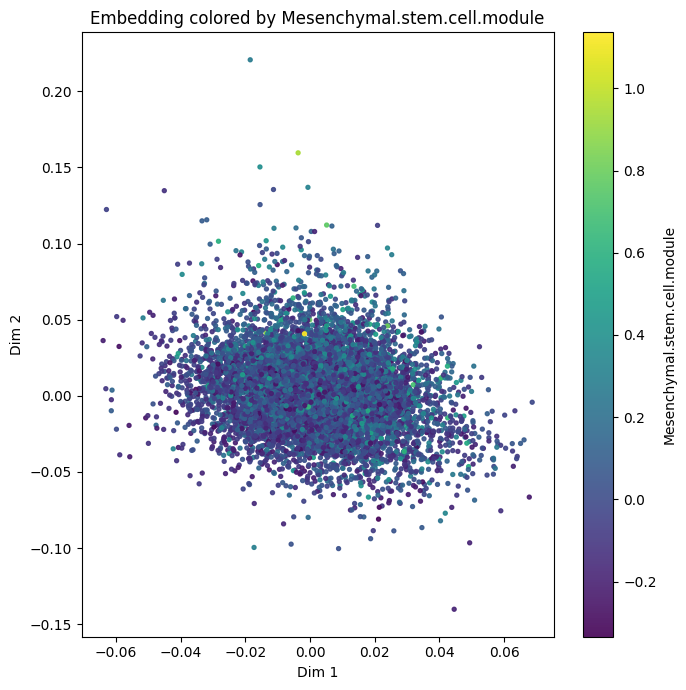

In [63]:
embeddings_key = "component4_e10"
desired_obs = 'Mesenchymal.stem.cell.module'

visualize_embedding(
    embedding=adata.obsm[embeddings_key],
    obs_values=adata.obs[desired_obs],
    cmap=plt.cm.viridis,
    c_bar_label="Mesenchymal.stem.cell.module",
    bbox_to_anchor=(1.23, 1.01)
)

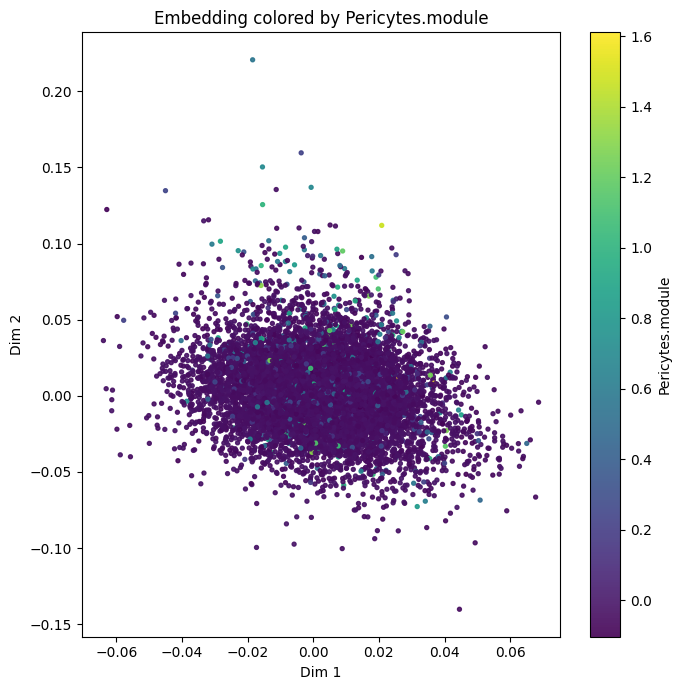

In [64]:
embeddings_key = "component4_e10"
desired_obs = 'Pericytes.module'

visualize_embedding(
    embedding=adata.obsm[embeddings_key],
    obs_values=adata.obs[desired_obs],
    cmap=plt.cm.viridis,
    c_bar_label="Pericytes.module",
    bbox_to_anchor=(1.23, 1.01)
)

In [103]:
embeddings_key = "component4_e10"
desired_obs = 'VEGF.pathway''

visualize_embedding(
    embedding=adata.obsm[embeddings_key],
    obs_values=adata.obs[desired_obs],
    cmap=plt.cm.viridis,
    c_bar_label="VEGF.pathway'",
    bbox_to_anchor=(1.23, 1.01)
)

SyntaxError: unterminated string literal (detected at line 2) (902517682.py, line 2)

In [ ]:
columns = adata.obs.columns.tolist()
for column in columns: 
    embeddings_key = "component4_e10"
    desired_obs = column

    visualize_embedding(
        embedding=adata.obsm[embeddings_key],
        obs_values=adata.obs[desired_obs],
        cmap=plt.cm.viridis,
        c_bar_label=desired_obs,
        bbox_to_anchor=(1.23, 1.01)
    )

/Users/jeromecho/Library/CloudStorage/OneDrive-Personal/Thesis/code/CellUntangler/src/visualization/visualization_functions.py:97: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


**QUESTIONS**
- Is using "everything else" to capture cell type really the best technique to use?
- Why does CellUntangler use the first latent subspace to reconstruct the genes that don't belong in the gene mask (when only the first latent subspace is used for reconstructing those genes that belong in the first gene mask)?
  A decision I need to might need to make (if the code doesn't already think about this and implement it)
  - Should all earlier subspaces contribute to the reconstruction of subsets of genes corresponding to later subspaces? Or, should only the last subset of genes (presumably corresponding to the largest number of genes) be reconstructed using the all latent subspaces up to the last subspace?
  - A sub-question: what guarantees disentanglement in models like CellUntangler?
  - Hmmm, if we stopped the gradient for all earlier subspaces when training later subspaces, would this ensure that earlier subspaces never "tweak" their parameters to get better at reconstructing a subset of genes unrelated to the subset of genes they should best reconstruct? 

What owu

**Worklist** 
- (HSSOC) Getting stuck on 2+ subspace CellUntangler (Get blocked on nuances of stopping gradients) 
- (Liver) Getting stuck on better benchmarking
- (Liver) Getting started on biological analysis of different dimensions + generating pairwise plots of disentangled dimensions 

**Ideas** 
- Might be useful to mix HGSOC dataset with non-cancerous cells to see how well the cell dissociation signal is captured in a particular latent space

**Deep Dives**
- What makes a "rotated" hyperbolic component "rotated"?
- How to visualize learnable curvatures in latent spaces? 

In [ ]:
itai 